#  Exploratory Data Analysis and Preprocessing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
top3_cities_df = pd.read_csv('/content/drive/MyDrive/820_Project_cleaned_dataset.csv')
top3_cities_df.head()

,review_id,user_id,business_id,stars_review,useful,funny,cool,text,date,name,...,compliment_cool,compliment_funny,compliment_writer,compliment_photos,active_years,elite_count,elite_flag,friends_count,compliment_total,cluster
0,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Zaika,...,0,0,0,0,11.131507,0,0,1,1,1
1,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1,1,2,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31,Dmitri's,...,0,0,0,0,10.723288,0,0,1,1,0
2,l3Wk_mvAog6XANIuGQ9C7Q,ZbqSHbgCjzVAqaa7NKWn5A,EQ-TZ2eeD_E0BHuvoaeG5Q,4,0,0,0,"Locals recommended Milktooth, and it's an amaz...",2015-08-19 14:31:45,Milktooth,...,0,0,0,0,9.556164,0,0,1,0,1
3,8JFGBuHMoiNDyfcxuWNtrA,smOvOajNG0lS4Pq7d8g4JQ,RZtGWDLCAtuipwaZ-UfjmQ,4,0,0,0,Good food--loved the gnocchi with marinara\nth...,2009-10-14 19:57:14,LaScala's,...,1,1,0,0,15.438356,0,0,44,8,3
4,OAhBYw8IQ6wlfw1owXWRWw,1C2lxzUo1Hyye4RFIXly3g,BVndHaLihEYbr76Z0CMEGw,5,0,0,0,"Great place for breakfast! I had the waffle, w...",2014-10-11 16:22:06,Mamas Kitchen,...,0,0,0,0,11.613699,0,0,3,0,3


## Data Cleaning

In [ ]:
top3_cities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1369708 entries, 0 to 1369707
Data columns (total 49 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   review_id           1369708 non-null  object 
 1   user_id             1369708 non-null  object 
 2   business_id         1369708 non-null  object 
 3   stars_review        1369708 non-null  int64  
 4   useful              1369708 non-null  int64  
 5   funny               1369708 non-null  int64  
 6   cool                1369708 non-null  int64  
 7   text                1369708 non-null  object 
 8   date                1369708 non-null  object 
 9   name                1369708 non-null  object 
 10  address             1365077 non-null  object 
 11  city                1369708 non-null  object 
 12  state               1369708 non-null  object 
 13  postal_code         1369523 non-null  float64
 14  latitude            1369708 non-null  float64
 15  longitude      

In [ ]:
top3_cities_df = top3_cities_df.dropna(subset=['text'])

top3_cities_df['address'] = top3_cities_df['address'].fillna('Unknown')
top3_cities_df['postal_code'] = top3_cities_df['postal_code'].astype(str).fillna('Unknown')
top3_cities_df['attributes'] = top3_cities_df['attributes'].fillna('{}')
top3_cities_df['friends'] = top3_cities_df['friends'].fillna('')
top3_cities_df['elite'] = top3_cities_df['elite'].fillna('')

top3_cities_df = top3_cities_df[top3_cities_df['text'].str.strip() != '']

print(top3_cities_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1369708 entries, 0 to 1369707
Data columns (total 49 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   review_id           1369708 non-null  object 
 1   user_id             1369708 non-null  object 
 2   business_id         1369708 non-null  object 
 3   stars_review        1369708 non-null  int64  
 4   useful              1369708 non-null  int64  
 5   funny               1369708 non-null  int64  
 6   cool                1369708 non-null  int64  
 7   text                1369708 non-null  object 
 8   date                1369708 non-null  object 
 9   name                1369708 non-null  object 
 10  address             1369708 non-null  object 
 11  city                1369708 non-null  object 
 12  state               1369708 non-null  object 
 13  postal_code         1369708 non-null  object 
 14  latitude            1369708 non-null  float64
 15  longitude      

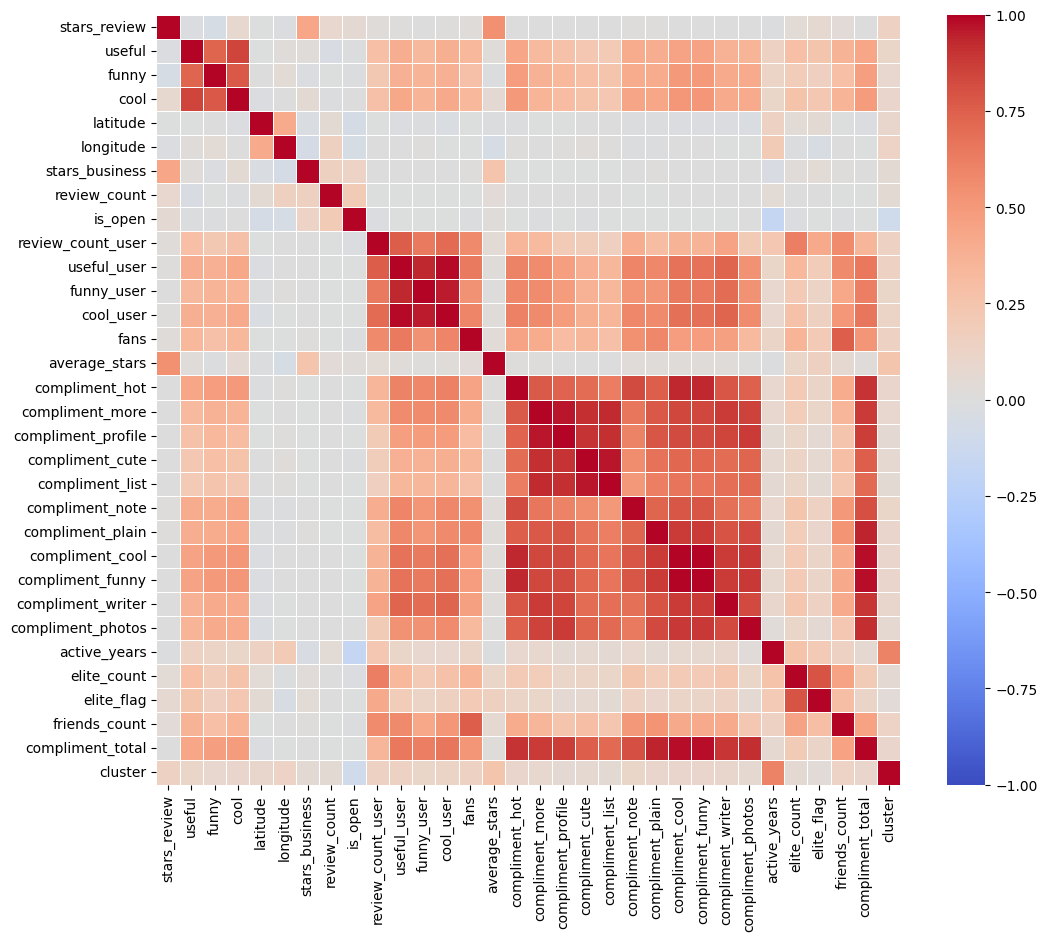

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = top3_cities_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            annot=False,
            cmap="coolwarm",
            linewidths=0.5,
            vmin=-1, vmax=1)

plt.show()

In [ ]:
top3_cities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1369708 entries, 0 to 1369707
Data columns (total 56 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   review_id           1369708 non-null  object        
 1   user_id             1369708 non-null  object        
 2   business_id         1369708 non-null  object        
 3   stars_review        1369708 non-null  int64         
 4   useful              1369708 non-null  int64         
 5   funny               1369708 non-null  int64         
 6   cool                1369708 non-null  int64         
 7   text                1369708 non-null  object        
 8   date                1369708 non-null  object        
 9   name                1369708 non-null  object        
 10  address             1369708 non-null  object        
 11  city                1369708 non-null  object        
 12  state               1369708 non-null  object        
 13  postal_code 

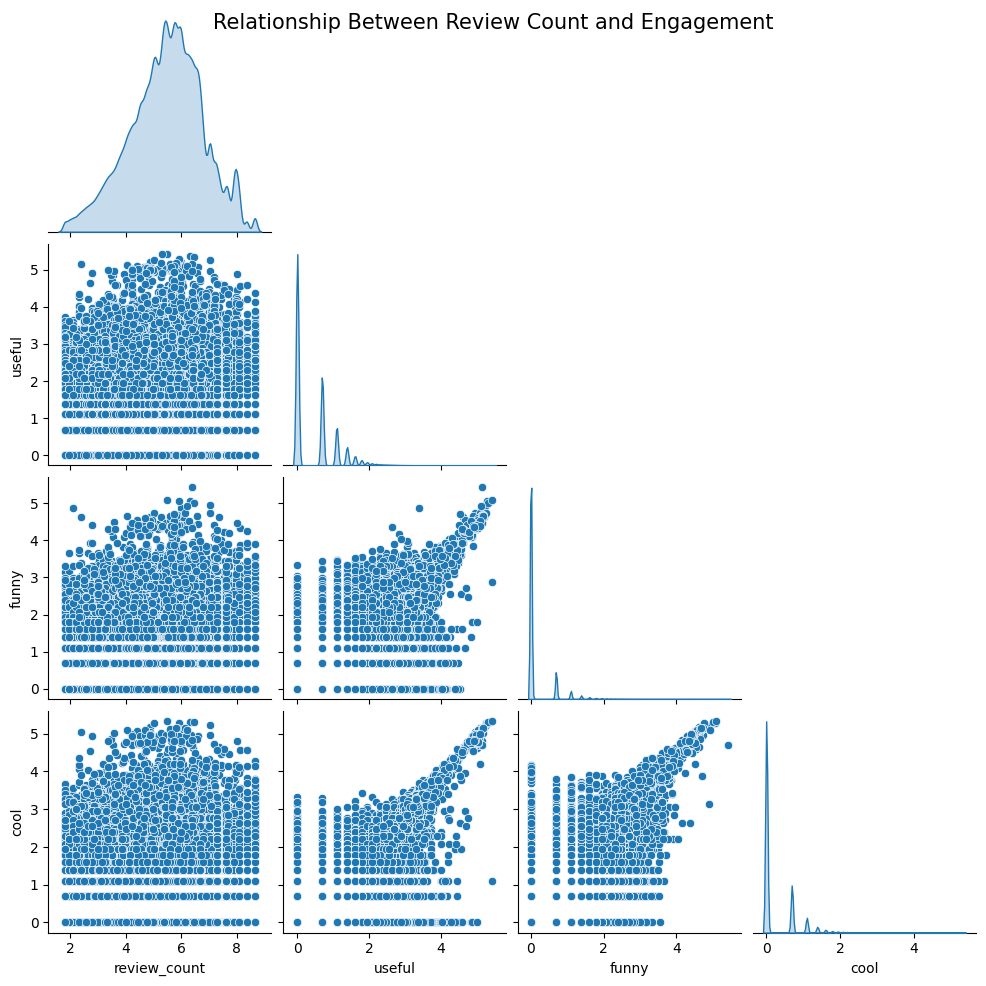

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

selected_columns = ["review_count", "useful", "funny", "cool"]

df_log = top3_cities_df[selected_columns].apply(np.log1p)

sns.pairplot(df_log, diag_kind="kde", corner=True)
plt.suptitle("Relationship Between Review Count and Engagement", fontsize=15, y=0.98)
plt.show()

The relationship plot shows a positive correlation between review_count and useful, funny, cool. Such positive relationship indicates that, more reviews means more users would participate the review.

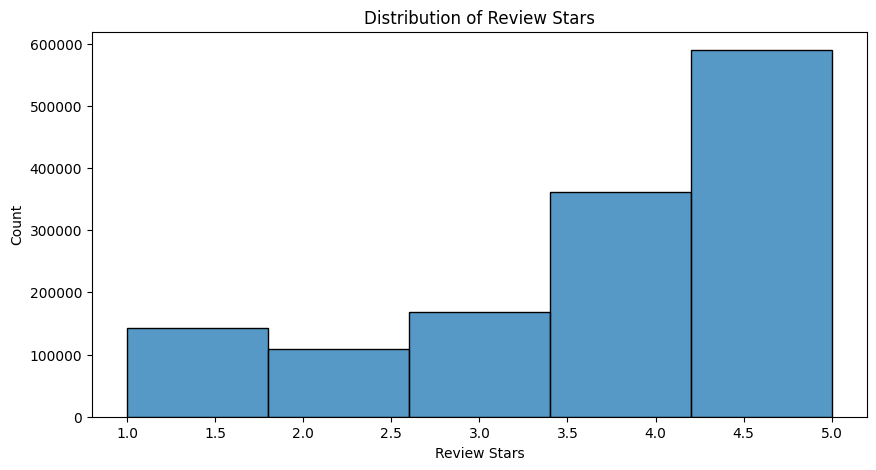

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 5))
sns.histplot(top3_cities_df['stars_review'], bins=5)
plt.xlabel('Review Stars')
plt.ylabel('Count')
plt.title('Distribution of Review Stars')
plt.show()

This histogram shows the distribution of Yelp review ratings, indicating that 5-star reviews are the most frequent, then 4-star reviews. Also, 1-3 star ratings are less frequent, which suggests a trend for users to give higher ratings.

For the heatmap, we can observe the distribution of top 3 cities with most reviews.

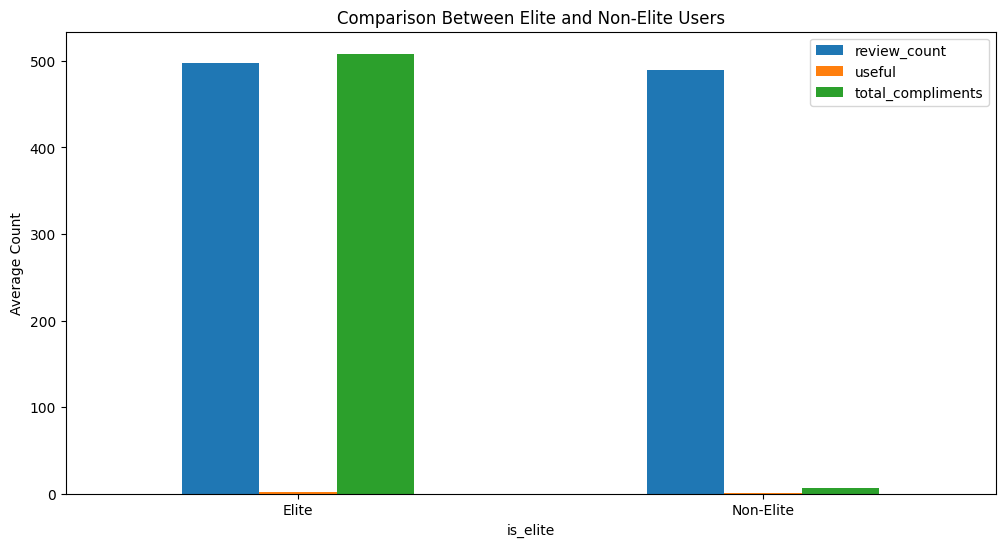

In [ ]:
compliment_columns = [
    'compliment_hot', 'compliment_more', 'compliment_profile',
    'compliment_cute', 'compliment_list', 'compliment_note',
    'compliment_plain', 'compliment_cool', 'compliment_funny',
    'compliment_writer', 'compliment_photos'
]

top3_cities_df['total_compliments'] = top3_cities_df[compliment_columns].sum(axis=1)
top3_cities_df['is_elite'] = top3_cities_df['elite'].apply(lambda x: 'Elite' if x != '' else 'Non-Elite')

top3_cities_df.groupby('is_elite')[['review_count', 'useful', 'total_compliments']].mean().plot(kind='bar', figsize=(12, 6))
plt.title('Comparison Between Elite and Non-Elite Users')
plt.ylabel('Average Count')
plt.xticks(rotation=0)
plt.show()


This bar chart compares elite and non-elite Yelp users, which shows that elite users have higher average review counts and total compliments, however, both groups have relatively low 'useful' votes.

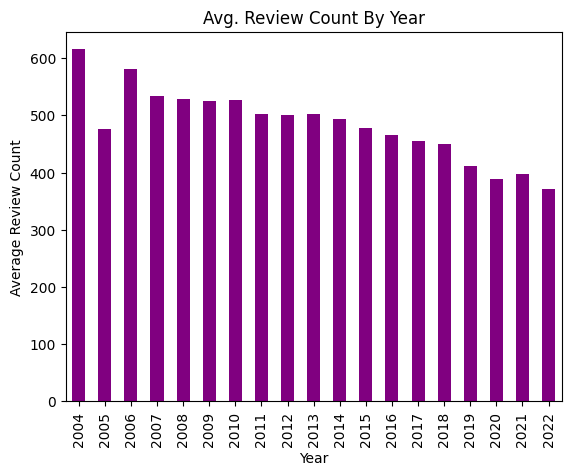

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

top3_cities_df['yelping_since'] = pd.to_datetime(top3_cities_df['yelping_since'])

top3_cities_df['yelping_year'] = top3_cities_df['yelping_since'].dt.year

top3_cities_df.groupby('yelping_year')['review_count'].mean().plot(kind='bar', color='purple')
plt.title('Avg. Review Count By Year')
plt.xlabel('Year')
plt.ylabel('Average Review Count')
plt.show()

This bar chart shows the average review count by year, which indicates a general decline in review activity over time, especially after 2017.

## Market Basket Analysis

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder

top3_cities_df = top3_cities_df.fillna({'categories': ''})


category_res = top3_cities_df['categories'].str.split(', ')

te = TransactionEncoder()
te_res = te.fit(category_res).transform(category_res)
category_df = pd.DataFrame(te_res, columns=te.columns_)
category_df

,Acai Bowls,Accessories,Accountants,Active Life,Acupuncture,Adult,Adult Education,Adult Entertainment,Afghan,African,...,Wine & Spirits,Wine Bars,Wine Tasting Classes,Wine Tasting Room,Wine Tours,Wineries,Women's Clothing,Wraps,Yelp Events,Yoga
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1369703,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1369704,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1369705,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1369706,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
frequent_categories = apriori(category_df, min_support=0.05, use_colnames=True)
frequent_categories.sort_values(by="support",ascending=False)

,support,itemsets
17,0.906105,(Restaurants)
12,0.364937,(Food)
15,0.310330,(Nightlife)
2,0.300416,(Bars)
36,0.300416,"(Nightlife, Bars)"
...,...,...
74,0.050943,"(Restaurants, Food, American (Traditional))"
91,0.050126,"(Specialty Food, Food, Restaurants)"
65,0.050126,"(Specialty Food, Restaurants)"
51,0.050046,"(Desserts, Restaurants)"


Most frequent categories is restaurants, which show that most yelp business is associated with category of restaurants. According to this result. We will select a detailed analysis of the catering industry in the follow-up analysis

In [ ]:
rules = association_rules(frequent_categories, metric="lift", min_threshold=1.0)

rules.sort_values(by='lift', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
165,(Wine & Spirits),"(Beer, Food)",0.053676,0.053676,0.053676,1.000000,18.630160,1.0,0.050795,inf,1.000000,1.000000,1.000000,1.000000
27,(Wine & Spirits),(Beer),0.053676,0.053676,0.053676,1.000000,18.630160,1.0,0.050795,inf,1.000000,1.000000,1.000000,1.000000
26,(Beer),(Wine & Spirits),0.053676,0.053676,0.053676,1.000000,18.630160,1.0,0.050795,inf,1.000000,1.000000,1.000000,1.000000
160,"(Beer, Food)",(Wine & Spirits),0.053676,0.053676,0.053676,1.000000,18.630160,1.0,0.050795,inf,1.000000,1.000000,1.000000,1.000000
162,"(Food, Wine & Spirits)",(Beer),0.053676,0.053676,0.053676,1.000000,18.630160,1.0,0.050795,inf,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,"(Nightlife, Bars)",(Restaurants),0.300416,0.906105,0.275129,0.915826,1.010729,1.0,0.002920,1.115492,0.015173,0.295395,0.103535,0.609733
60,(Nightlife),(Restaurants),0.310330,0.906105,0.283767,0.914405,1.009161,1.0,0.002576,1.096973,0.013162,0.304253,0.088401,0.613789
61,(Restaurants),(Nightlife),0.906105,0.310330,0.283767,0.313172,1.009161,1.0,0.002576,1.004139,0.096676,0.304253,0.004122,0.613789
49,(Restaurants),(Event Planning & Services),0.906105,0.066827,0.060579,0.066856,1.000429,1.0,0.000026,1.000031,0.004570,0.066398,0.000031,0.486675


This result presents the strongest association rules among categories of restaurants, showing that "Wine & Spirits" is highly associated with "Beer" and "Food" because lift equals to 18.63.